In [47]:
import pandas as pd

In [48]:
df = pd.read_csv('water_potability.csv')

In [49]:
df.shape

(3276, 10)

In [50]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [51]:
df = df.drop_duplicates()

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [53]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [54]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [55]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


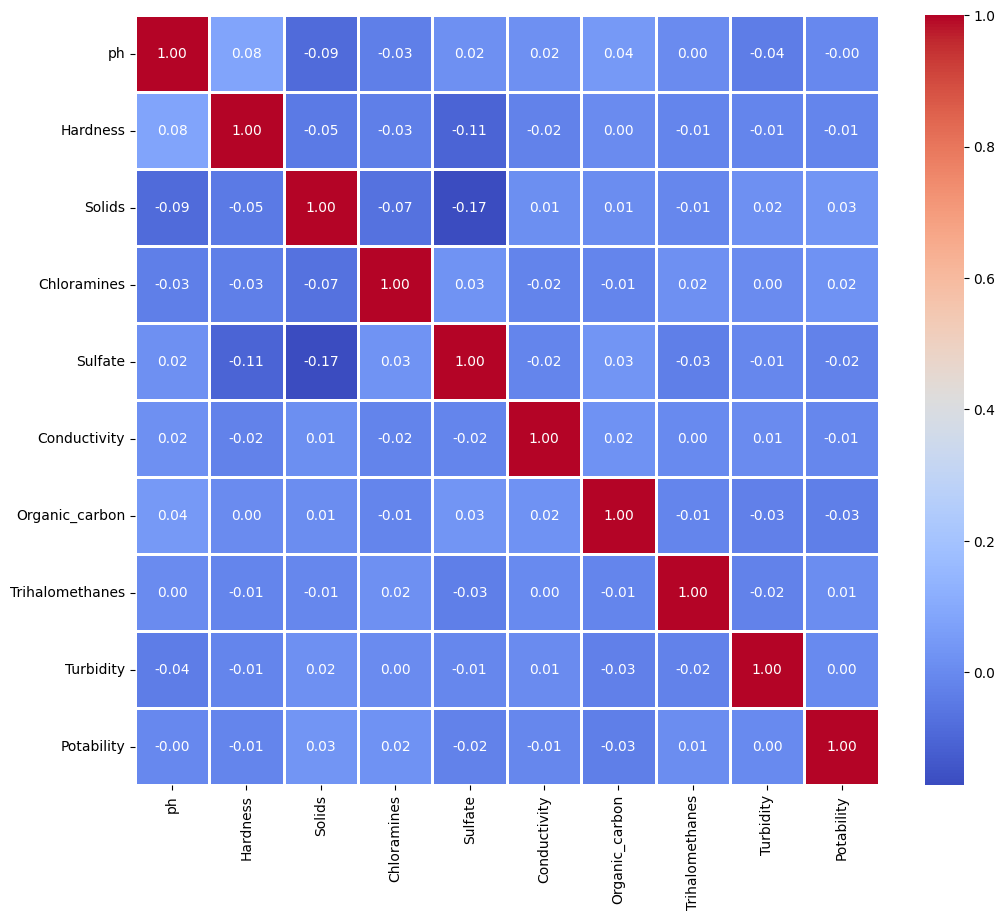

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.show()

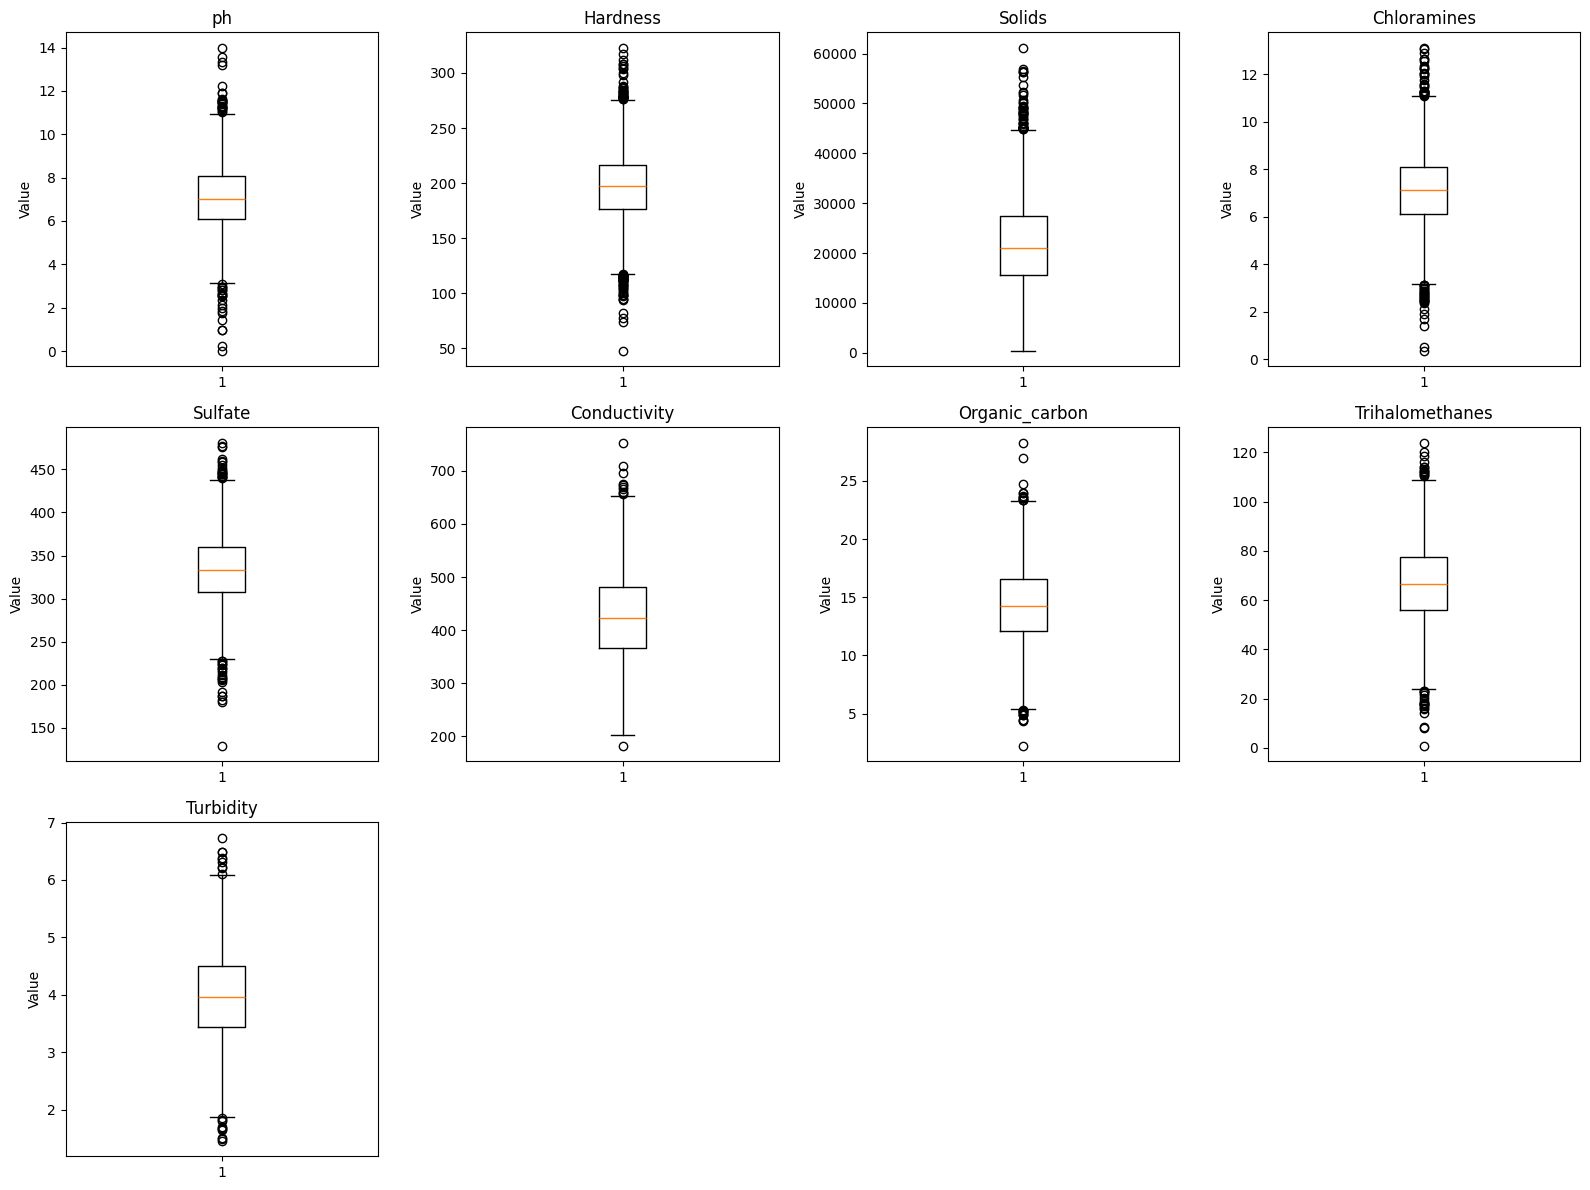

In [57]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='float').columns

fig, axes = plt.subplots(
    nrows=(len(numeric_cols) + 3) // 4,
    ncols=4,
    figsize=(16, 4 * ((len(numeric_cols) + 3) // 4))
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [58]:
X = df.drop('Potability',axis=1)
y = df['Potability']

In [59]:
y.value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [61]:
from sklearn.impute import SimpleImputer

num_col = X_train.select_dtypes(include='number').columns
impute = SimpleImputer(strategy='median')
X_train[num_col] = impute.fit_transform(X_train[num_col])
X_test[num_col] = impute.transform(X_test[num_col])

In [65]:
from sklearn.preprocessing import StandardScaler


ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scale, y_train)
y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)

print('Train')
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, zero_division=0))
print(recall_score(y_train, y_pred_train,zero_division=0))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred,zero_division=0))
print(recall_score(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Train
0.5206106870229008
0.4068471337579618
0.5
[[853 745]
 [511 511]]
              precision    recall  f1-score   support

           0       0.63      0.53      0.58      1598
           1       0.41      0.50      0.45      1022

    accuracy                           0.52      2620
   macro avg       0.52      0.52      0.51      2620
weighted avg       0.54      0.52      0.53      2620

test
0.524390243902439
0.4146341463414634
0.53125
[[208 192]
 [120 136]]
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       400
           1       0.41      0.53      0.47       256

    accuracy                           0.52       656
   macro avg       0.52      0.53      0.52       656
weighted avg       0.55      0.52      0.53       656



In [67]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=101,class_weight='balanced')
rf.fit(X_train_scale, y_train)
y_pred = rf.predict(X_test_scale)
y_pred_train = rf.predict(X_train_scale)

print('Train')
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, zero_division=0))
print(recall_score(y_train, y_pred_train,zero_division=0))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred,zero_division=0))
print(recall_score(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Train
1.0
1.0
1.0
[[1598    0]
 [   0 1022]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1598
           1       1.00      1.00      1.00      1022

    accuracy                           1.00      2620
   macro avg       1.00      1.00      1.00      2620
weighted avg       1.00      1.00      1.00      2620

test
0.6554878048780488
0.5815217391304348
0.41796875
[[323  77]
 [149 107]]
              precision    recall  f1-score   support

           0       0.68      0.81      0.74       400
           1       0.58      0.42      0.49       256

    accuracy                           0.66       656
   macro avg       0.63      0.61      0.61       656
weighted avg       0.64      0.66      0.64       656



In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


rf = RandomForestClassifier(class_weight='balanced')
param = [{
    'n_estimators':[51,101,201],
    'max_depth':[2,3,4]
}]
grid = GridSearchCV(estimator=rf, param_grid=param, cv=5, n_jobs=-1)
grid.fit(X_train_scale, y_train)
y_pred = grid.predict(X_test_scale)
y_pred_train = grid.predict(X_train_scale)

print('Train')
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, zero_division=0))
print(recall_score(y_train, y_pred_train,zero_division=0))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred,zero_division=0))
print(recall_score(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Train
0.716793893129771
0.6745635910224439
0.5293542074363993
[[1337  261]
 [ 481  541]]
              precision    recall  f1-score   support

           0       0.74      0.84      0.78      1598
           1       0.67      0.53      0.59      1022

    accuracy                           0.72      2620
   macro avg       0.70      0.68      0.69      2620
weighted avg       0.71      0.72      0.71      2620

test
0.625
0.5247524752475248
0.4140625
[[304  96]
 [150 106]]
              precision    recall  f1-score   support

           0       0.67      0.76      0.71       400
           1       0.52      0.41      0.46       256

    accuracy                           0.62       656
   macro avg       0.60      0.59      0.59       656
weighted avg       0.61      0.62      0.61       656



In [69]:
from xgboost import XGBClassifier

xg = XGBClassifier()
param = [{
    'n_estimators':[51,101,201],
    'max_depth':[2,3,4]
}]
grid = GridSearchCV(estimator=xg, param_grid=param, cv=5, n_jobs=-1)
grid.fit(X_train_scale, y_train)
y_pred = grid.predict(X_test_scale)
y_pred_train = grid.predict(X_train_scale)

print(grid.best_params_)
print('Train')
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, zero_division=0))
print(recall_score(y_train, y_pred_train,zero_division=0))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred,zero_division=0))
print(recall_score(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


{'max_depth': 4, 'n_estimators': 51}
Train
0.8522900763358778
0.9308005427408412
0.6712328767123288
[[1547   51]
 [ 336  686]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1598
           1       0.93      0.67      0.78      1022

    accuracy                           0.85      2620
   macro avg       0.88      0.82      0.83      2620
weighted avg       0.86      0.85      0.85      2620

test
0.6402439024390244
0.5641025641025641
0.34375
[[332  68]
 [168  88]]
              precision    recall  f1-score   support

           0       0.66      0.83      0.74       400
           1       0.56      0.34      0.43       256

    accuracy                           0.64       656
   macro avg       0.61      0.59      0.58       656
weighted avg       0.63      0.64      0.62       656



In [70]:
from sklearn.naive_bayes import GaussianNB

naive = GaussianNB()
naive.fit(X_train_scale, y_train)
y_pred = naive.predict(X_test_scale)
y_pred_train = naive.predict(X_train_scale)

print(grid.best_params_)
print('Train')
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, zero_division=0))
print(recall_score(y_train, y_pred_train,zero_division=0))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred,zero_division=0))
print(recall_score(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


{'max_depth': 4, 'n_estimators': 51}
Train
0.6267175572519084
0.5502283105022832
0.23581213307240703
[[1401  197]
 [ 781  241]]
              precision    recall  f1-score   support

           0       0.64      0.88      0.74      1598
           1       0.55      0.24      0.33      1022

    accuracy                           0.63      2620
   macro avg       0.60      0.56      0.54      2620
weighted avg       0.61      0.63      0.58      2620

test
0.614329268292683
0.5161290322580645
0.1875
[[355  45]
 [208  48]]
              precision    recall  f1-score   support

           0       0.63      0.89      0.74       400
           1       0.52      0.19      0.28       256

    accuracy                           0.61       656
   macro avg       0.57      0.54      0.51       656
weighted avg       0.59      0.61      0.56       656

